## Student Performance in Exams

Data from: https://www.kaggle.com/datasets/spscientist/students-performance-in-exams

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings("ignore")

In [3]:
df = pd.read_csv("data/StudentsPerformance.csv")

In [4]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


#### Check for missing values

In [5]:
df.isna().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

#### Check for duplicates

In [6]:
df.duplicated().sum()

np.int64(0)

#### Check data types

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


#### Check number of unique values in each column

In [8]:
df.nunique()

gender                          2
race/ethnicity                  5
parental level of education     6
lunch                           2
test preparation course         2
math score                     81
reading score                  72
writing score                  77
dtype: int64

#### Check statistics of the numerical data

In [9]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


#### Explore the none numerical data

In [13]:
print("Categories in 'gender' variable: ")
print(df["gender"].unique())

print("Categories in 'race/ethnicity' variable: ")
print(df["race/ethnicity"].unique())

print("Categories in 'parental level of education' variable: ")
print(df["parental level of education"].unique())

print("Categories in 'lunch' variable: ")
print(df["lunch"].unique())

print("Categories in 'test preparation course' variable: ")
print(df["test preparation course"].unique())

Categories in 'gender' variable: 
['female' 'male']
Categories in 'race/ethnicity' variable: 
['group B' 'group C' 'group A' 'group D' 'group E']
Categories in 'parental level of education' variable: 
["bachelor's degree" 'some college' "master's degree" "associate's degree"
 'high school' 'some high school']
Categories in 'lunch' variable: 
['standard' 'free/reduced']
Categories in 'test preparation course' variable: 
['none' 'completed']


In [14]:
# Define numerical columns
numericalFeatures = [feature for feature in df.columns if df[feature].dtype != "O"]
# Define categorial columns
categorialFeatures = [feature for feature in df.columns if df[feature].dtype == "O"]

print (f"There are {len(numericalFeatures)} : {numericalFeatures}")
print (f"There are {len(categorialFeatures)} : {categorialFeatures}")

There are 3 : ['math score', 'reading score', 'writing score']
There are 5 : ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course']


#### Add info for Total Score and Average Score

In [15]:
df["Total Score"] = df["math score"] + df["reading score"] + df["writing score"]
df["Average Score"] = df["Total Score"] / 3

In [16]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,Total Score,Average Score
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


In [22]:
# Check how many students got full marks
readingFull = df[df["reading score"] == 100]["Average Score"].count()
writingFull = df[df["writing score"] == 100]["Average Score"].count()
mathsFull = df[df["math score"] == 100]["Average Score"].count()

allFull = df[(df["reading score"] == 100) & 
              (df["writing score"] == 100) & 
              (df["math score"] == 100)]["Average Score"].count()

print(f"Number of students with full marks in Reading: {readingFull}")
print(f"Number of students with full marks in Writing: {writingFull}")
print(f"Number of students with full marks in Maths: {mathsFull}")
print(f"Number of students with full marks in all tests: {allFull}")

Number of students with full marks in Reading: 17
Number of students with full marks in Writing: 14
Number of students with full marks in Maths: 7
Number of students with full marks in all tests: 3


In [23]:
# Check how many students got less than 20% average
readingLess20 = df[df["reading score"] <= 20]["Average Score"].count()
writingLess20 = df[df["writing score"] <= 20]["Average Score"].count()
mathsLess20 = df[df["math score"] <= 20]["Average Score"].count()

allLess20 = df[(df["reading score"] <= 20) & 
              (df["writing score"] <= 20) & 
              (df["math score"] <= 20)]["Average Score"].count()

print(f"Number of students with less than 20% in Reading: {readingLess20}")
print(f"Number of students with less than 20% in Writing: {writingLess20}")
print(f"Number of students with less than 20% in Maths: {mathsLess20}")
print(f"Number of students with less than 20% across all tests: {allLess20}")

Number of students with less than 20% in Reading: 1
Number of students with less than 20% in Writing: 3
Number of students with less than 20% in Maths: 4
Number of students with less than 20% across all tests: 1


### Visualise the data

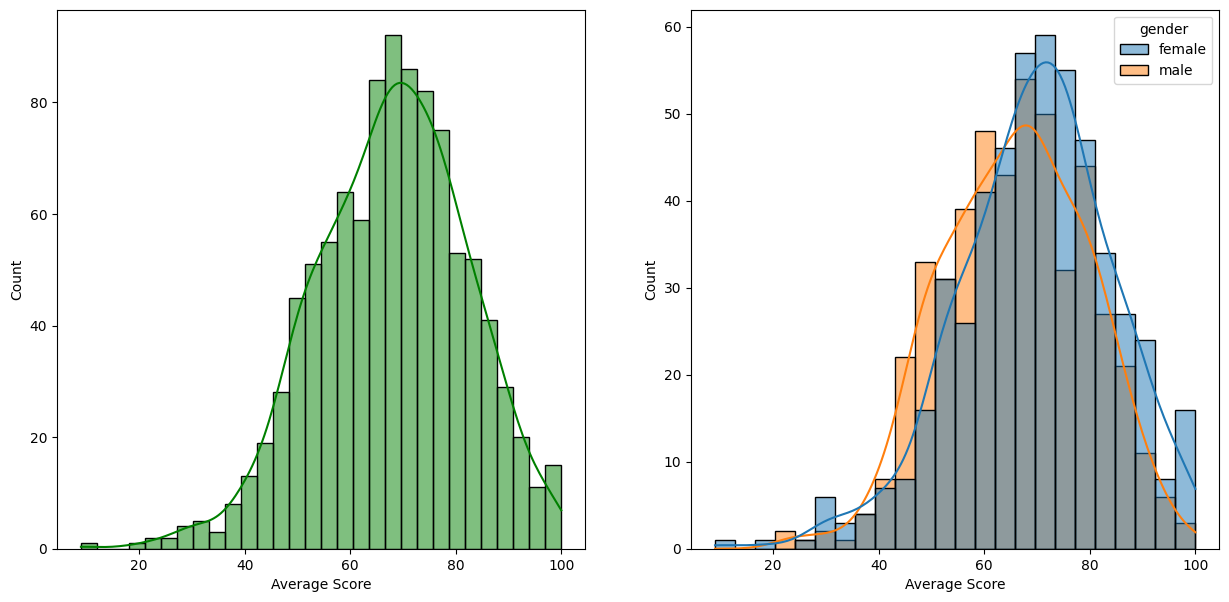

In [29]:
fig, axis = plt.subplots(1, 2, figsize=(15, 7))
plt.subplot(121)
sns.histplot(df, x="Average Score", bins=30, kde=True, color="g")
plt.subplot(122)
sns.histplot(df, x="Average Score", kde=True, hue="gender")
plt.show()

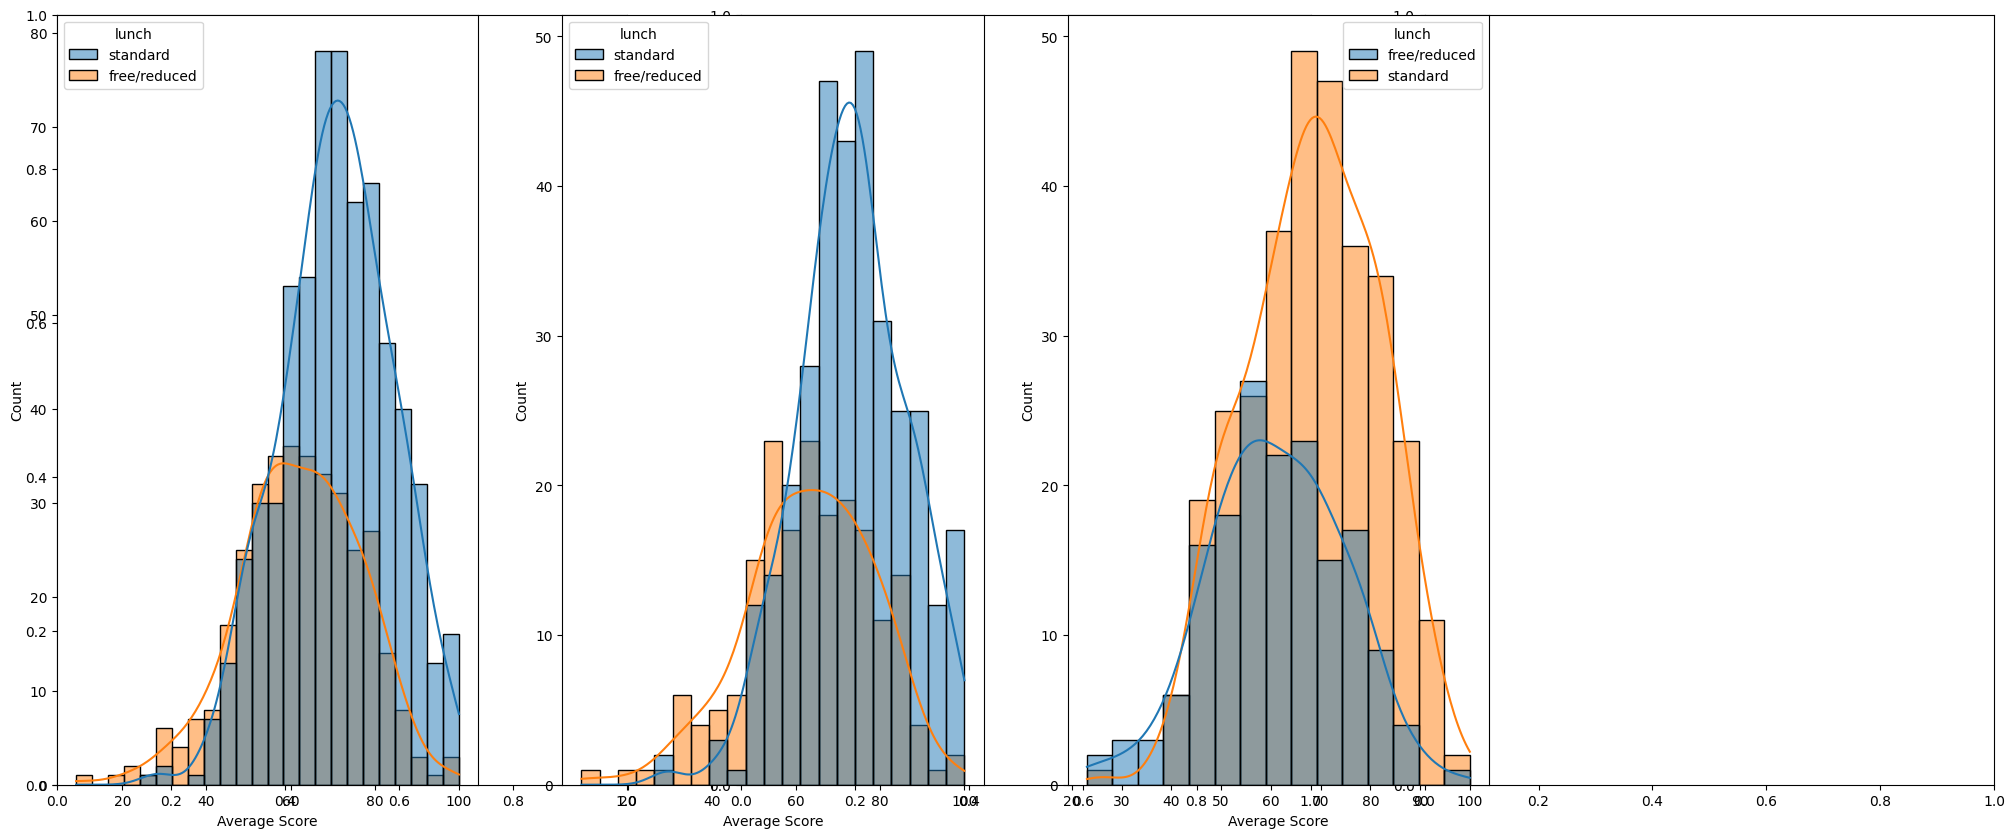

In [34]:
fig, axis = plt.subplots(1, 3, figsize=(25, 10))
plt.subplot(141)
sns.histplot(df, x="Average Score", kde=True, hue="lunch")
plt.subplot(142)
sns.histplot(df[df.gender == "female"], x="Average Score", kde=True, hue="lunch")
plt.subplot(143)
sns.histplot(df[df.gender == "male"], x="Average Score", kde=True, hue="lunch")
plt.show()